# Laboratorio 2 - Complejidad y búsqueda de hiperparámetros

En este laboratorio del caso AlpesHearth, se busca fortalecer el modelo inicial de regresión lineal desarrollado previamente para estimar el riesgo cardiovascular, explorando enfoques más avanzados de modelado y evaluando su capacidad de generalización y estabilidad. A partir del conjunto de datos ya depurado, el énfasis estará en la construcción y comparación de modelos de regresión polinomial y regularizada (Ridge y Lasso), utilizando pipelines y validación cruzada con búsqueda sistemática de hiperparámetros. Se analizará el impacto de la complejidad en el desempeño predictivo mediante métricas como RMSE, MAE y R², así como a través de curvas de validación y el estudio del trade-off sesgo-varianza. Posteriormente, se seleccionará el mejor modelo considerando no solo su desempeño promedio sino también su estabilidad, y se estimarán intervalos de confianza mediante bootstrapping para cuantificar la incertidumbre. Finalmente, se realizará un análisis cuantitativo, cualitativo y conceptual de los resultados, comunicando de manera clara las decisiones metodológicas y sus implicaciones técnicas y estratégicas para la organización.

## 1. Importar Librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import numpy as np
import math

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, KFold
from sklearn import set_config
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.formula.api import ols
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.utils import resample
from sklearn.model_selection import validation_curve


## 2. Carga y preparación de los datos

### Carga de los datos:

In [2]:
datos_pacientes = pd.read_csv('./data/Datos Lab 1.csv')
datos2 = datos_pacientes.copy()
datos2.head()

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,isDx5313,"November 08, 2023",M,44.0,114.300,1.720,38.600,100.000,112/83,228.0,...,High,N,172.000,0.581,112.0,83.0,Hypertension Stage 1,121.0,19.880,HIGH
1,LHCK2961,20/03/2024,F,57.0,92.923,1.842,33.116,106.315,101/91,158.0,...,High,Y,184.172,0.577,101.0,91.0,Hypertension Stage 2,57.0,16.833,INTERMEDIARY
2,WjVn1699,2021-05-27,F,NaN,73.400,1.650,27.000,78.100,90/74,135.0,...,High,N,165.000,0.473,90.0,74.0,Normal,45.0,12.600,LOW
3,dCDO1109,"April 18, 2022",F,35.0,113.300,1.780,35.800,79.600,92/89,158.0,...,Moderate,Y,178.000,0.447,92.0,89.0,Hypertension Stage 1,94.0,14.920,HIGH
4,pnpE1080,01/11/2024,F,48.0,102.200,1.750,33.400,106.700,121/68,207.0,...,Low,Y,175.000,0.610,121.0,68.0,Elevated,128.0,18.870,HIGH


### Preparación:

In [3]:
datos2 = datos_pacientes.copy()

Como ya se hizo una exploración previa de los datos, ya se puede hacer un segundo modelo de regresión lineal basado en la información que tenemos. Este modelo va a tener aspectos diferentes en términos de preparación de datos con el fin de hacerlo más preciso que el anterior. 

### Completitud

Ya se sabe que la mayoría de las categorías tienen datos faltantes. Esto se comprobó en el modelo pasado usando la siguiente función:

In [4]:
pd.DataFrame({
    "faltantes": datos2.isnull().sum(),
    "porcentaje_%": (datos2.isnull().sum() / len(datos2) * 100).round(2)
})

,faltantes,porcentaje_%
Patient ID,0,0.00
Date of Service,0,0.00
Sex,0,0.00
Age,68,4.15
Weight (kg),73,4.45
Height (m),61,3.72
BMI,53,3.23
Abdominal Circumference (cm),61,3.72
Blood Pressure (mmHg),0,0.00
Total Cholesterol (mg/dL),68,4.15


A diferencia del modelo pasado, en este modelo se van a calcular todas las columnas que pueden ser rellenadas y después sí se van a eliminar las que no pudieron ser calculadas.

#### BMI, Weight (kg), Height (m), Height (cm), Waist-to-Height Ratio, Abdominal Circumference (cm)

In [5]:
# ===== Config: columnas (ajusta si tus nombres difieren) =====
COL_H_M   = "Height (m)"
COL_H_CM  = "Height (cm)"
COL_W     = "Weight (kg)"
COL_BMI   = "BMI"
COL_WHR   = "Waist-to-Height Ratio"
COL_WAIST = "Abdominal Circumference (cm)"

cols_focus = [COL_BMI, COL_H_CM, COL_H_M, COL_W, COL_WHR, COL_WAIST]

# ===== 1) Asegurar tipo numérico en las columnas de interés =====
for c in cols_focus:
    if c in datos2.columns:
        datos2[c] = pd.to_numeric(datos2[c], errors="coerce")

# ===== 2) Definir helpers de "altura válida" para evitar divisiones por cero =====
h_m_valid  = datos2[COL_H_M].notna()  & (datos2[COL_H_M]  > 0)
h_cm_valid = datos2[COL_H_CM].notna() & (datos2[COL_H_CM] > 0)
w_valid    = datos2[COL_W].notna()    & (datos2[COL_W]    > 0)
bmi_valid  = datos2[COL_BMI].notna()  & (datos2[COL_BMI]  > 0)
waist_valid= datos2[COL_WAIST].notna()& (datos2[COL_WAIST]> 0)
whr_valid  = datos2[COL_WHR].notna()  & (datos2[COL_WHR]  > 0)

# ===== 3) Relleno iterativo (porque unas columnas permiten rellenar otras y viceversa) =====
# Repetimos unas cuantas veces hasta estabilizar.
for _ in range(5):
    before = datos2[cols_focus].isna().sum().sum()

    # --- Altura: m <-> cm ---
    # Height (cm) = Height (m) * 100
    mask = datos2[COL_H_CM].isna() & datos2[COL_H_M].notna() & (datos2[COL_H_M] > 0)
    datos2.loc[mask, COL_H_CM] = datos2.loc[mask, COL_H_M] * 100.0

    # Height (m) = Height (cm) / 100
    mask = datos2[COL_H_M].isna() & datos2[COL_H_CM].notna() & (datos2[COL_H_CM] > 0)
    datos2.loc[mask, COL_H_M] = datos2.loc[mask, COL_H_CM] / 100.0

    # Recalcular válidos (pueden haber cambiado)
    h_m_valid  = datos2[COL_H_M].notna()  & (datos2[COL_H_M]  > 0)
    h_cm_valid = datos2[COL_H_CM].notna() & (datos2[COL_H_CM] > 0)

    # --- BMI y Weight (kg) ---
    # BMI = Weight / Height(m)^2
    mask = datos2[COL_BMI].isna() & w_valid & h_m_valid
    datos2.loc[mask, COL_BMI] = datos2.loc[mask, COL_W] / (datos2.loc[mask, COL_H_M] ** 2)

    # Weight = BMI * Height(m)^2
    mask = datos2[COL_W].isna() & bmi_valid & h_m_valid
    datos2.loc[mask, COL_W] = datos2.loc[mask, COL_BMI] * (datos2.loc[mask, COL_H_M] ** 2)

    # Recalcular válidos (pueden haber cambiado)
    w_valid   = datos2[COL_W].notna()   & (datos2[COL_W]   > 0)
    bmi_valid = datos2[COL_BMI].notna() & (datos2[COL_BMI] > 0)

    # --- Waist-to-Height Ratio y Abdominal Circumference ---
    # Asumimos: Waist-to-Height Ratio = Abdominal Circumference (cm) / Height (cm)
    # Ratio = waist_cm / height_cm
    mask = datos2[COL_WHR].isna() & waist_valid & h_cm_valid
    datos2.loc[mask, COL_WHR] = datos2.loc[mask, COL_WAIST] / datos2.loc[mask, COL_H_CM]

    # waist_cm = Ratio * height_cm
    mask = datos2[COL_WAIST].isna() & whr_valid & h_cm_valid
    datos2.loc[mask, COL_WAIST] = datos2.loc[mask, COL_WHR] * datos2.loc[mask, COL_H_CM]

    # Recalcular válidos (pueden haber cambiado)
    waist_valid = datos2[COL_WAIST].notna() & (datos2[COL_WAIST] > 0)
    whr_valid   = datos2[COL_WHR].notna()   & (datos2[COL_WHR]   > 0)

    after = datos2[cols_focus].isna().sum().sum()
    if after == before:  # ya no cambia nada
        break

Se realizaron correcciones de calidad de datos asegurando primero que las variables antropométricas estuvieran en formato numérico válido. Posteriormente, se imputaron valores faltantes utilizando relaciones matemáticas conocidas entre las variables (altura en metros y centímetros, BMI y peso, y la relación cintura-altura), aplicando un proceso iterativo hasta completar la información de forma coherente y consistente sin introducir valores arbitrarios.

#### Systolic + Diastolic <-> Blood Pressure (mmHg)

In [6]:
bp_split = datos2["Blood Pressure (mmHg)"].str.split("/", expand=True)

In [7]:
cond_sys = (
    datos2["Systolic BP"].isna() &
    datos2["Blood Pressure (mmHg)"].notna()
)

datos2.loc[cond_sys, "Systolic BP"] = bp_split.loc[cond_sys, 0].astype(float)

In [8]:
cond_dia = (
    datos2["Diastolic BP"].isna() &
    datos2["Blood Pressure (mmHg)"].notna()
)

datos2.loc[cond_dia, "Diastolic BP"] = bp_split.loc[cond_dia, 1].astype(float)

Se cuentan las líneas faltantes:

In [9]:
pd.DataFrame({
    "faltantes": datos2.isnull().sum(),
    "porcentaje_%": (datos2.isnull().sum() / len(datos2) * 100).round(2)
})


,faltantes,porcentaje_%
Patient ID,0,0.00
Date of Service,0,0.00
Sex,0,0.00
Age,68,4.15
Weight (kg),1,0.06
Height (m),3,0.18
BMI,1,0.06
Abdominal Circumference (cm),1,0.06
Blood Pressure (mmHg),0,0.00
Total Cholesterol (mg/dL),68,4.15


Se puede ver que el número de filas con datos faltantes se redució de manera significativa. Sin embargo, filas que aún tienen datos faltantes que no pueden ser calculados. Para estas filas se puede hacer una imputación con mediana.

Eliminar las que no tienen CVD Risk Score ya que este es el target:

In [10]:
datos2 = datos2.dropna(subset=["CVD Risk Score"])

Eliminar las que faltan para Abdominal Circumference (cm), Waist-to-Height Ratio, Heicht (cm), Height (m), Weight (kg) y BMI ya que el porcentaje de datos faltantes es menor a 1%

In [11]:
datos2 = datos2.dropna(subset=["Waist-to-Height Ratio", "Abdominal Circumference (cm)", "Height (cm)", "Height (cm)", "Weight (kg)", "BMI"])

In [12]:
pd.DataFrame({
    "faltantes": datos2.isnull().sum(),
    "porcentaje_%": (datos2.isnull().sum() / len(datos2) * 100).round(2)
})

,faltantes,porcentaje_%
Patient ID,0,0.00
Date of Service,0,0.00
Sex,0,0.00
Age,67,4.17
Weight (kg),0,0.00
Height (m),0,0.00
BMI,0,0.00
Abdominal Circumference (cm),0,0.00
Blood Pressure (mmHg),0,0.00
Total Cholesterol (mg/dL),68,4.24


Imputación con mediana de Age, Total Cholesterol (mg/dL), HDL (mg/dL), Fasting Blood Sugar (mg/dL), Estimated LDL (mg/dL):

In [13]:
cols_imputar_mediana = [
    "Age",
    "Total Cholesterol (mg/dL)",
    "HDL (mg/dL)",
    "Fasting Blood Sugar (mg/dL)",
    "Estimated LDL (mg/dL)"
]

medianas = {}
for c in cols_imputar_mediana:
    if c in datos2.columns:
        med = datos2[c].median(skipna=True)
        medianas[c] = med
        datos2[c] = datos2[c].fillna(med)

print("Medianas usadas para imputación:")
print(pd.Series(medianas).sort_index())

Medianas usadas para imputación:
Age                             46.0
Estimated LDL (mg/dL)          112.0
Fasting Blood Sugar (mg/dL)    115.0
HDL (mg/dL)                     56.0
Total Cholesterol (mg/dL)      198.0
dtype: float64


In [14]:
pd.DataFrame({
    "faltantes": datos2.isnull().sum(),
    "porcentaje_%": (datos2.isnull().sum() / len(datos2) * 100).round(2)
})

,faltantes,porcentaje_%
Patient ID,0,0.0
Date of Service,0,0.0
Sex,0,0.0
Age,0,0.0
Weight (kg),0,0.0
Height (m),0,0.0
BMI,0,0.0
Abdominal Circumference (cm),0,0.0
Blood Pressure (mmHg),0,0.0
Total Cholesterol (mg/dL),0,0.0


Después de este proceso, no quedan valores faltantes en los datos que serán usados para el modelo. 

### Unicidad

Para los problemas de unicidad, se va a analizar la unicidad por filas y unicidad por Patient ID:

#### Unicidad de filas

Es necesario eliminar estas filas ya que resultados repetidos pueden sesgar el modelo final.

In [15]:
datos2.duplicated().sum()

np.int64(150)

In [16]:
datos2 = datos2.drop_duplicates()

#### Unicidad por Patient ID y Date of Service

Se debe normalizar el formato de la fecha primero:

In [17]:
datos2["Date of Service"] = pd.to_datetime(
    datos2["Date of Service"],
    format="mixed",   # permite múltiples formatos
    dayfirst=True,    # interpreta correctamente DD/MM/YYYY
    errors="coerce"   # valores inválidos → NaT
)

In [18]:
n_dups = datos2.duplicated(subset=["Patient ID", "Date of Service"], keep="first").sum()
print("Filas duplicadas por (Patient ID, Date of Service):", int(n_dups))

Filas duplicadas por (Patient ID, Date of Service): 111


Como estas filas tienen duplicados el Patient ID y Date of Service al mismo tiempo, se van a eliminar, pues no tiene sentido que un paciente tenga datos diferentes en el mismo día. 

In [19]:
datos2 = (
    datos2.sort_values(["Patient ID", "Date of Service"])
      .drop_duplicates(subset=["Patient ID", "Date of Service"], keep="first")
      .reset_index(drop=True)
)

In [20]:
datos2.duplicated(
    subset=["Patient ID", "Date of Service"]
).sum()

np.int64(0)

De esta manera, se eliminaron los duplicados.

### Validez

Además de los rangos específicos, para esta detección de validez, se va a considerar que cualquier dato fuera de Q1-IQR*1.5 o Q3+IQR*1.5 atípico y no se tendrá en cuenta para el modelo.

Los datos faltantes serán imputados con la mediana.

En esta sección se realiza un proceso de validación y corrección de la calidad de los datos numéricos. Primero, se define un conjunto de rangos clínicamente plausibles para cada variable y se identifican valores inválidos, reemplazando números negativos y valores fuera de dichos rangos por valores faltantes (NaN). Posteriormente, se detectan valores atípicos mediante el criterio del rango intercuartílico (IQR × 1.5), los cuales también se consideran inválidos. Finalmente, los valores faltantes generados se imputan utilizando la mediana de cada variable, garantizando un conjunto de datos consistente y completo sin introducir sesgos extremos, y se genera un reporte para verificar que no queden datos faltantes tras la corrección.

In [21]:
df = datos2.copy()


# 1) Define rangos válidos

rangos = {
    "Age": (0, 120),
    "Weight (kg)": (20, 300),
    "Height (m)": (0.9, 2.5),
    "Height (cm)": (90, 250),
    "BMI": (10, 80),
    "Abdominal Circumference (cm)": (40, 200),
    "Waist-to-Height Ratio": (0.2, 1.2),
    "Total Cholesterol (mg/dL)": (50, 500),
    "HDL (mg/dL)": (10, 150),
    "Fasting Blood Sugar (mg/dL)": (40, 400),
    "Systolic BP": (60, 250),
    "Diastolic BP": (30, 150),
    "Estimated LDL (mg/dL)": (0, 400),
    "CVD Risk Score": (0, 100)
}


# 2) Columnas numéricas

num_cols = df.select_dtypes(include="number").columns.tolist()


# 3) Negativos -> NaN

for c in num_cols:
    df.loc[df[c] < 0, c] = np.nan


# 4) Rangos duros -> NaN

for c, (lo, hi) in rangos.items():
    if c in df.columns:
        df.loc[(df[c] < lo) | (df[c] > hi), c] = np.nan


# 5) IQR*1.5 -> NaN (solo para columnas numéricas)

for c in num_cols:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1

    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr

    df.loc[(df[c] < low) | (df[c] > high), c] = np.nan


# 6) Imputar con mediana

for c in num_cols:
    df[c] = df[c].fillna(df[c].median())


# 7) Reporte

faltantes_por_col = df[num_cols].isna().sum().sort_values(ascending=False)
print("Faltantes por columna (después de validar + imputar):")
print(faltantes_por_col)

print("\nFilas con al menos 1 faltante en numéricas:", int(df[num_cols].isna().any(axis=1).sum()))

# Guardar resultado
datos2 = df

Faltantes por columna (después de validar + imputar):
Age                             0
Weight (kg)                     0
Height (m)                      0
BMI                             0
Abdominal Circumference (cm)    0
Total Cholesterol (mg/dL)       0
HDL (mg/dL)                     0
Fasting Blood Sugar (mg/dL)     0
Height (cm)                     0
Waist-to-Height Ratio           0
Systolic BP                     0
Diastolic BP                    0
Estimated LDL (mg/dL)           0
CVD Risk Score                  0
dtype: int64

Filas con al menos 1 faltante en numéricas: 0


### Consistencia

Para la revisión y corregimiento de la consistencia, se va a hacer lo siguiente:

- Normalizar y estandarizar variables categóricas
- Convertir Date of Service a fecha
- Recalcular BMI y Waist-to-Height Ratio usando sus componentes
- Asegurarse de que Systolic BP < Diastolic BP
- Recalcula Blood Pressure Category

In [22]:
df = datos2.copy()


# 0) Helpers

def clean_str(s):
    """Limpia strings: strip + upper. Mantiene NaN."""
    return s.astype(str).str.strip().str.upper().replace({"NAN": np.nan, "NONE": np.nan, "": np.nan})

def map_yes_no(series):
    """Convierte múltiples representaciones a 'Y'/'N'."""
    s = clean_str(series)
    mapping = {
        "Y": "Y", "YES": "Y", "SI": "Y", "SÍ": "Y", "TRUE": "Y", "T": "Y", "1": "Y",
        "N": "N", "NO": "N", "FALSE": "N", "F": "N", "0": "N"
    }
    return s.map(mapping).fillna(s)

def bp_category(sys, dia):
    """Categoría de presión arterial (regla típica AHA 2017)."""
    if pd.isna(sys) or pd.isna(dia):
        return np.nan
    # Crisis hipertensiva (opcional): sys>=180 o dia>=120
    # if sys >= 180 or dia >= 120:
    #     return "HYPERTENSIVE CRISIS"
    if sys < 120 and dia < 80:
        return "NORMAL"
    if 120 <= sys < 130 and dia < 80:
        return "ELEVATED"
    if (130 <= sys < 140) or (80 <= dia < 90):
        return "HYPERTENSION STAGE 1"
    if (sys >= 140) or (dia >= 90):
        return "HYPERTENSION STAGE 2"
    return np.nan


# 1) Consistencia de fechas

if "Date of Service" in df.columns:
    df["Date of Service"] = pd.to_datetime(df["Date of Service"], errors="coerce").dt.normalize()


# 2) Consistencia de categóricas

# Sex -> M/F (todo lo demás queda como NaN u OTHER si prefieres)
if "Sex" in df.columns:
    s = clean_str(df["Sex"])
    sex_map = {"M": "M", "MALE": "M", "F": "F", "FEMALE": "F"}
    df["Sex"] = s.map(sex_map)

# Y/N columns
for col in ["Smoking Status", "Diabetes Status", "Family History of CVD"]:
    if col in df.columns:
        df[col] = map_yes_no(df[col])

# Physical Activity Level
if "Physical Activity Level" in df.columns:
    s = clean_str(df["Physical Activity Level"])
    pal_map = {
        "LOW": "LOW", "BAJO": "LOW",
        "MODERATE": "MODERATE", "MODERADO": "MODERATE",
        "HIGH": "HIGH", "ALTO": "HIGH"
    }
    df["Physical Activity Level"] = s.map(pal_map)

# Blood Pressure Category (solo estandariza texto; luego la recalculamos)
if "Blood Pressure Category" in df.columns:
    s = clean_str(df["Blood Pressure Category"])
    bpc_map = {
        "NORMAL": "NORMAL",
        "ELEVATED": "ELEVATED", "ELEVADA": "ELEVATED",
        "HYPERTENSION STAGE 1": "HYPERTENSION STAGE 1",
        "HYPERTENSION STAGE 2": "HYPERTENSION STAGE 2",
        "HIPERTENSIÓN ETAPA 1": "HYPERTENSION STAGE 1",
        "HIPERTENSION ETAPA 1": "HYPERTENSION STAGE 1",
        "HIPERTENSIÓN ETAPA 2": "HYPERTENSION STAGE 2",
        "HIPERTENSION ETAPA 2": "HYPERTENSION STAGE 2",
    }
    df["Blood Pressure Category"] = s.map(bpc_map).fillna(s)


# 3) Coherencia matemática: alturas, BMI, ratio

# Asegurar numéricos relevantes
for c in ["Height (m)", "Height (cm)", "Weight (kg)", "BMI",
          "Abdominal Circumference (cm)", "Waist-to-Height Ratio",
          "Systolic BP", "Diastolic BP"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Altura: recalcular cm y m para que siempre coincidan
h_m = df["Height (m)"] if "Height (m)" in df.columns else None
h_cm = df["Height (cm)"] if "Height (cm)" in df.columns else None

if h_m is not None and h_cm is not None:
    # Si hay Height(m), fuerza Height(cm)
    m_ok = df["Height (m)"].notna() & (df["Height (m)"] > 0)
    df.loc[m_ok, "Height (cm)"] = df.loc[m_ok, "Height (m)"] * 100

    # Si solo hay Height(cm), fuerza Height(m)
    cm_ok = df["Height (cm)"].notna() & (df["Height (cm)"] > 0)
    df.loc[cm_ok, "Height (m)"] = df.loc[cm_ok, "Height (cm)"] / 100

# BMI: recalcular desde Weight y Height(m)
if all(c in df.columns for c in ["Weight (kg)", "Height (m)", "BMI"]):
    w_ok = df["Weight (kg)"].notna() & (df["Weight (kg)"] > 0)
    hm_ok = df["Height (m)"].notna() & (df["Height (m)"] > 0)
    recalc_mask = w_ok & hm_ok
    df.loc[recalc_mask, "BMI"] = df.loc[recalc_mask, "Weight (kg)"] / (df.loc[recalc_mask, "Height (m)"] ** 2)

# Waist-to-Height Ratio: recalcular desde cintura(cm) y altura(cm)
if all(c in df.columns for c in ["Abdominal Circumference (cm)", "Height (cm)", "Waist-to-Height Ratio"]):
    waist_ok = df["Abdominal Circumference (cm)"].notna() & (df["Abdominal Circumference (cm)"] > 0)
    hcm_ok = df["Height (cm)"].notna() & (df["Height (cm)"] > 0)
    recalc_mask = waist_ok & hcm_ok
    df.loc[recalc_mask, "Waist-to-Height Ratio"] = df.loc[recalc_mask, "Abdominal Circumference (cm)"] / df.loc[recalc_mask, "Height (cm)"]


# 4) Consistencia lógica: presión arterial

fixed_swaps = 0
if all(c in df.columns for c in ["Systolic BP", "Diastolic BP"]):
    swap_mask = df["Systolic BP"].notna() & df["Diastolic BP"].notna() & (df["Systolic BP"] < df["Diastolic BP"])
    fixed_swaps = int(swap_mask.sum())
    # swap
    df.loc[swap_mask, ["Systolic BP", "Diastolic BP"]] = df.loc[swap_mask, ["Diastolic BP", "Systolic BP"]].to_numpy()

# Si existe "Blood Pressure (mmHg)" string, puedes opcionalmente reconstruirla desde sys/dia
if all(c in df.columns for c in ["Systolic BP", "Diastolic BP"]) and "Blood Pressure (mmHg)" in df.columns:
    sys_ok = df["Systolic BP"].notna()
    dia_ok = df["Diastolic BP"].notna()
    mask = sys_ok & dia_ok
    df.loc[mask, "Blood Pressure (mmHg)"] = (
        df.loc[mask, "Systolic BP"].round(0).astype(int).astype(str)
        + "/"
        + df.loc[mask, "Diastolic BP"].round(0).astype(int).astype(str)
    )

# Recalcular Blood Pressure Category desde sys/dia
recalc_cat_count = 0
if all(c in df.columns for c in ["Systolic BP", "Diastolic BP", "Blood Pressure Category"]):
    before = df["Blood Pressure Category"].copy()
    df["Blood Pressure Category"] = df.apply(lambda r: bp_category(r["Systolic BP"], r["Diastolic BP"]), axis=1)
    recalc_cat_count = int((before != df["Blood Pressure Category"]).sum(skipna=False))


# 5) Reporte simple

print("=== REPORTE DE CONSISTENCIA ===")
print("Swaps hechos (Systolic < Diastolic):", fixed_swaps)
if "Blood Pressure Category" in df.columns:
    print("Cambios en Blood Pressure Category (aprox):", recalc_cat_count)

# Valores únicos (para revisar rápido)
for col in ["Sex", "Smoking Status", "Diabetes Status", "Family History of CVD", "Physical Activity Level", "Blood Pressure Category"]:
    if col in df.columns:
        print(f"\nValores únicos en {col}:")
        print(df[col].value_counts(dropna=False))

# Guardar resultado
datos2 = df


=== REPORTE DE CONSISTENCIA ===
Swaps hechos (Systolic < Diastolic): 52
Cambios en Blood Pressure Category (aprox): 11

Valores únicos en Sex:
Sex
F    676
M    668
Name: count, dtype: int64

Valores únicos en Smoking Status:
Smoking Status
Y    691
N    653
Name: count, dtype: int64

Valores únicos en Diabetes Status:
Diabetes Status
Y    679
N    665
Name: count, dtype: int64

Valores únicos en Family History of CVD:
Family History of CVD
N    685
Y    659
Name: count, dtype: int64

Valores únicos en Physical Activity Level:
Physical Activity Level
HIGH        462
MODERATE    449
LOW         433
Name: count, dtype: int64

Valores únicos en Blood Pressure Category:
Blood Pressure Category
HYPERTENSION STAGE 2    552
HYPERTENSION STAGE 1    445
NORMAL                  258
ELEVATED                 89
Name: count, dtype: int64


## 4. Construcción del Pipeline de Preprocesamiento

### 4.1 Transformaciones de calidad de los datos

In [23]:
def limpiar_columnas(df):
    df = df.copy()

    # Asegurar Y/N -> 1/0 (por si aún quedara en texto)
    yn_cols = ["Smoking Status", "Diabetes Status", "Family History of CVD"]
    mapping = {"Y": 1, "N": 0, "YES": 1, "NO": 0, "TRUE": 1, "FALSE": 0, "1": 1, "0": 0}

    for col in yn_cols:
        if col in df.columns:
            s = df[col]

            # Si viene como texto, mapeamos. Si viene numérico, lo dejamos como número.
            if pd.api.types.is_string_dtype(s) or s.dtype == "object":
                s = s.astype(str).str.strip().str.upper()
                df[col] = s.map(mapping).astype(float)
            else:
                df[col] = pd.to_numeric(s, errors="coerce")

    # Estandarizar Sex y Physical Activity Level (por si hay variaciones)
    if "Sex" in df.columns:
        df["Sex"] = df["Sex"].astype(str).str.strip().str.upper().replace({"MALE":"M", "FEMALE":"F", "NAN": np.nan})

    if "Physical Activity Level" in df.columns:
        df["Physical Activity Level"] = (
            df["Physical Activity Level"].astype(str).str.strip().str.upper()
            .replace({"MODERADO":"MODERATE", "BAJO":"LOW", "ALTO":"HIGH", "NAN": np.nan})
        )

    return df

limpieza = FunctionTransformer(limpiar_columnas)

### 4.2 Selección y exclusión de variables

In [24]:
data = datos2.copy()

target = "CVD Risk Score"

feature_cols = [
    "Age",
    "Sex",
    "Smoking Status",
    "Diabetes Status",
    "Family History of CVD",
    "Physical Activity Level",
    "BMI",
    "Abdominal Circumference (cm)",
    "Systolic BP",
    "Diastolic BP",
    "Estimated LDL (mg/dL)",
    "Fasting Blood Sugar (mg/dL)",
]

X = data[feature_cols].copy()
y = data[target].copy()

El conjunto de datos se divide en entrenamiento (75%) y prueba (25%) para evaluar el modelo de forma objetiva. Además, se muestran las dimensiones resultantes de cada subconjunto.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=1
)

X_train.shape, X_test.shape

((1008, 12), (336, 12))

### 4.3 Separación por tipo de variable (numéricas y categóricas)

In [26]:
numeric_features = [
    "Age","BMI","Abdominal Circumference (cm)",
    "Systolic BP","Diastolic BP",
    "Estimated LDL (mg/dL)",
    "Fasting Blood Sugar (mg/dL)",
    "Smoking Status","Diabetes Status","Family History of CVD",
]

categorical_features = [
    "Sex",
    "Physical Activity Level"
]

### 4.4 Generación de características polinomiales

In [27]:
numeric_transformer_poly = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(include_bias=False))  # degree se ajusta por grid
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary")),
])

### 4.5 Ensamblaje del pipeline completo

In [28]:
preprocessor_poly = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_poly, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)


pipeline_poly = Pipeline(steps=[
    ("limpieza", limpieza),
    ("preproc", preprocessor_poly),
    ("model", LinearRegression())
])

## 5. Búsqueda de hiperparámetros con GridSearchCV

In [29]:
param_grid_poly = {
    "preproc__num__poly__degree": [1, 2, 3]
}

grid_poly = GridSearchCV(
    estimator=pipeline_poly,
    param_grid=param_grid_poly,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

grid_poly.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'preproc__num__poly__degree': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displa

## 6. Evaluación del modelo polinomial

### 6.1 Mejor configuración encontrada

In [30]:
mejor_modelo_poly = grid_poly.best_estimator_

print("Best params:", grid_poly.best_params_)
print("Best CV RMSE:", round(-grid_poly.best_score_ , 3))

Best params: {'preproc__num__poly__degree': 1}
Best CV RMSE: 1.254


### 6.2 Predicciones sobre el conjunto de prueba

In [31]:
y_train_pred = mejor_modelo_poly.predict(X_train)

y_test_pred = mejor_modelo_poly.predict(X_test)

### 6.3 Reporte de métricas

In [32]:
# ===== Métricas TRAIN =====
rmse_poly_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_poly_train  = mean_absolute_error(y_train, y_train_pred)
r2_poly_train   = r2_score(y_train, y_train_pred)

# ===== Métricas TEST =====
rmse_poly_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_poly_test  = mean_absolute_error(y_test, y_test_pred)
r2_poly_test   = r2_score(y_test, y_test_pred)

In [33]:
print("\n===== POLYNOMIAL REGRESSION (SIN REGULARIZACIÓN) =====")

print("\n--- Train ---")
print(f"RMSE: {rmse_poly_train:.3f}")
print(f"MAE : {mae_poly_train:.3f}")
print(f"R²  : {r2_poly_train:.3f}")

print("\n--- Test ---")
print(f"RMSE: {rmse_poly_test:.3f}")
print(f"MAE : {mae_poly_test:.3f}")
print(f"R²  : {r2_poly_test:.3f}")


===== POLYNOMIAL REGRESSION (SIN REGULARIZACIÓN) =====

--- Train ---
RMSE: 1.226
MAE : 0.900
R²  : 0.753

--- Test ---
RMSE: 1.428
MAE : 0.963
R²  : 0.655


## 7. Curvas de validación y análisis de complejidad

### 7.1 Generación de validation curves

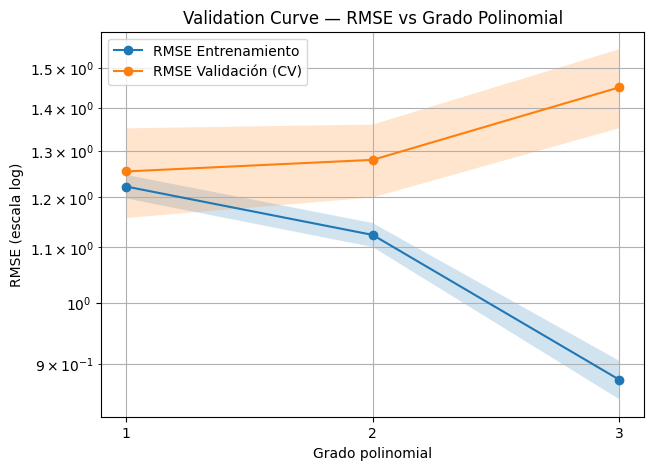

Grado 1: RMSE_train=1.2221 | RMSE_val=1.2544
Grado 2: RMSE_train=1.1241 | RMSE_val=1.2797
Grado 3: RMSE_train=0.8753 | RMSE_val=1.4505

Mejor grado según RMSE CV: 1


In [34]:
param_range = [1, 2, 3]

train_scores_rmse, val_scores_rmse = validation_curve(
    estimator=pipeline_poly,
    X=X_train,
    y=y_train,
    param_name="preproc__num__poly__degree",
    param_range=param_range,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

train_rmse = -train_scores_rmse
val_rmse   = -val_scores_rmse

train_rmse_mean = train_rmse.mean(axis=1)
train_rmse_std  = train_rmse.std(axis=1)
val_rmse_mean   = val_rmse.mean(axis=1)
val_rmse_std    = val_rmse.std(axis=1)

plt.figure(figsize=(7,5))
plt.plot(param_range, train_rmse_mean, marker="o", label="RMSE Entrenamiento")
plt.plot(param_range, val_rmse_mean, marker="o", label="RMSE Validación (CV)")
plt.fill_between(param_range, train_rmse_mean-train_rmse_std, train_rmse_mean+train_rmse_std, alpha=0.2)
plt.fill_between(param_range, val_rmse_mean-val_rmse_std, val_rmse_mean+val_rmse_std, alpha=0.2)

plt.xticks(param_range)
plt.xlabel("Grado polinomial")
plt.ylabel("RMSE (escala log)")
plt.title("Validation Curve — RMSE vs Grado Polinomial")
plt.yscale("log")
plt.grid(True, which="both")
plt.legend()
plt.show()

for d, tr, va in zip(param_range, train_rmse_mean, val_rmse_mean):
    print(f"Grado {d}: RMSE_train={tr:.4f} | RMSE_val={va:.4f}")

best_degree_rmse = param_range[int(np.argmin(val_rmse_mean))]
print("\nMejor grado según RMSE CV:", best_degree_rmse)

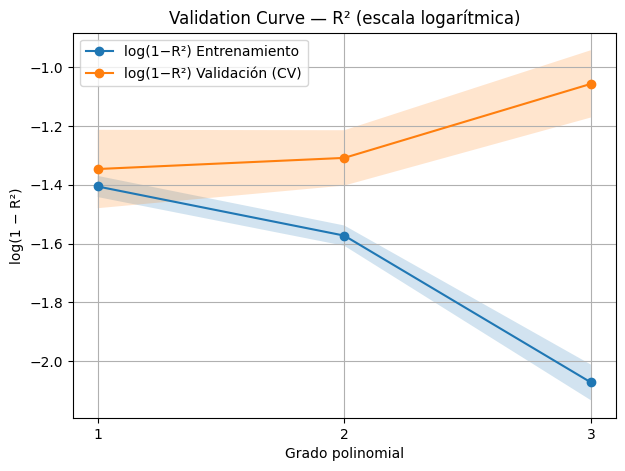

Grado 1: R2_train=0.7547 | R2_val=0.7397
Grado 2: R2_train=0.7925 | R2_val=0.7297
Grado 3: R2_train=0.8741 | R2_val=0.6522


In [35]:
train_scores_r2, val_scores_r2 = validation_curve(
    estimator=pipeline_poly,
    X=X_train,
    y=y_train,
    param_name="preproc__num__poly__degree",
    param_range=param_range,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

train_r2_mean = train_scores_r2.mean(axis=1)
train_r2_std  = train_scores_r2.std(axis=1)
val_r2_mean   = val_scores_r2.mean(axis=1)
val_r2_std    = val_scores_r2.std(axis=1)

# escala log válida
eps = 1e-8
train_log = np.log(1 - train_r2_mean + eps)
val_log   = np.log(1 - val_r2_mean + eps)

train_log_std = train_r2_std / (1 - train_r2_mean + eps)
val_log_std   = val_r2_std / (1 - val_r2_mean + eps)

plt.figure(figsize=(7,5))
plt.plot(param_range, train_log, marker="o", label="log(1−R²) Entrenamiento")
plt.plot(param_range, val_log, marker="o", label="log(1−R²) Validación (CV)")
plt.fill_between(param_range, train_log-train_log_std, train_log+train_log_std, alpha=0.2)
plt.fill_between(param_range, val_log-val_log_std, val_log+val_log_std, alpha=0.2)

plt.xticks(param_range)
plt.xlabel("Grado polinomial")
plt.ylabel("log(1 − R²)")
plt.title("Validation Curve — R² (escala logarítmica)")
plt.grid(True)
plt.legend()
plt.show()

for d, tr, va in zip(param_range, train_r2_mean, val_r2_mean):
    print(f"Grado {d}: R2_train={tr:.4f} | R2_val={va:.4f}")

### 7.2 Análisis sesgo-varianza

El análisis de las curvas de validación muestra que al aumentar el grado polinomial disminuye el error de entrenamiento, evidenciando una reducción del sesgo, mientras que el error de validación aumenta a partir del grado 2, indicando un incremento de la varianza y la aparición de sobreajuste. El modelo de grado 3 presenta el mejor ajuste sobre los datos de entrenamiento pero el peor desempeño en validación, lo que confirma una pérdida de capacidad de generalización. En contraste, el modelo de grado 1 exhibe la menor brecha entre entrenamiento y validación y el menor RMSE en validación cruzada, alcanzando el mejor equilibrio sesgo–varianza y constituyéndose como la configuración óptima entre las evaluadas.

## 8. Modelo Ridge (Regularización L2)

### Modelo Lineal Regularizado con Ridge

#### 8.1 Construcción del pipeline Ridge

In [36]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor_base = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

pipeline_linear = Pipeline([
    ("limpieza", limpieza),
    ("preproc", preprocessor_base),
    ("model", LinearRegression())
])

pipeline_ridge = Pipeline([
    ("limpieza", limpieza),
    ("preproc", preprocessor_base),
    ("model", Ridge())
])

#### 8.2 Definición de hiperparámetros (α)

In [37]:
param_grid_ridge = {
    "model__alpha": np.logspace(-4, 1.5, 25),
    
    #estrategias de escalamiento
    "preproc__num__scaler": [
        StandardScaler(),
        MinMaxScaler(),
        RobustScaler()
    ]
}

In [38]:
kfold = KFold(n_splits=10, shuffle=True, random_state = 1)

#### 8.3 Búsqueda con GridSearchCV

In [39]:
grid_ridge = GridSearchCV(
    estimator=pipeline_ridge,
    param_grid=param_grid_ridge,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

In [40]:
%%time
grid_ridge.fit(X_train, y_train)

CPU times: total: 1.3 s
Wall time: 2.84 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': array([1.0000...16227766e+01]), 'preproc__num__scaler': [StandardScaler(), MinMaxScaler(), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : th

In [41]:
print("Mejores hiperparámetros Ridge:", grid_ridge.best_params_)
print("Best CV RMSE:", round(-grid_ridge.best_score_ , 3))

Mejores hiperparámetros Ridge: {'model__alpha': np.float64(6.493816315762113), 'preproc__num__scaler': StandardScaler()}
Best CV RMSE: 1.239


In [42]:
best_ridge = grid_ridge.best_estimator_

In [43]:
y_pred_ridge_train  = best_ridge.predict(X_train)

y_pred_ridge_test = best_ridge.predict(X_test)

#### 8.4 Evaluación del modeo Ridge (Métricas)

In [44]:
rmse_ridge_train = np.sqrt(mean_squared_error(y_train, y_pred_ridge_train))
mae_ridge_train  = mean_absolute_error(y_train, y_pred_ridge_train)
r2_ridge_train   = r2_score(y_train, y_pred_ridge_train)

rmse_ridge_test = np.sqrt(mean_squared_error(y_test, y_pred_ridge_test))
mae_ridge_test  = mean_absolute_error(y_test, y_pred_ridge_test)
r2_ridge_test   = r2_score(y_test, y_pred_ridge_test)

In [45]:
print("\n===== RIDGE REGRESSION =====")

print("\n--- Train ---")
print(f"RMSE: {rmse_ridge_train:.3f}")
print(f"MAE : {mae_ridge_train:.3f}")
print(f"R²  : {r2_ridge_train:.3f}")

print("\n--- Test ---")
print(f"RMSE: {rmse_ridge_test:.3f}")
print(f"MAE : {mae_ridge_test:.3f}")
print(f"R²  : {r2_ridge_test:.3f}")


===== RIDGE REGRESSION =====

--- Train ---
RMSE: 1.226
MAE : 0.901
R²  : 0.753

--- Test ---
RMSE: 1.427
MAE : 0.963
R²  : 0.655


### Modelo Polinomial Regularizado con Ridge

#### 8.1 Construcción del pipeline Ridge

In [46]:
pipeline_ridge_poly = Pipeline([
    ("limpieza", limpieza),
    ("preproc", preprocessor_poly),
    ("model", Ridge())
])

#### 8.2 Definición de hiperparámetros (α)

In [47]:

param_grid_ridge_poly = {
    "preproc__num__poly__degree": [1, 2, 3],
    "model__alpha": np.logspace(-4, 1.5, 25),

    #estrategias de escalamiento
    "preproc__num__scaler": [
        StandardScaler(),
        MinMaxScaler(),
        RobustScaler()
    ]
}

In [48]:
kfold = KFold(
    n_splits=10,
    shuffle=True,
    random_state=1
)

#### 8.3 Búsqueda con GridSearchCV

In [49]:
grid_ridge_poly = GridSearchCV(
    estimator=pipeline_ridge_poly,
    param_grid=param_grid_ridge_poly,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

In [50]:
%%time
grid_ridge_poly.fit(X_train, y_train)

CPU times: total: 4.14 s
Wall time: 10.1 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': array([1.0000...16227766e+01]), 'preproc__num__poly__degree': [1, 2, ...], 'preproc__num__scaler': [StandardScaler(), MinMaxScaler(), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosi

In [51]:
print("\n===== RIDGE POLINOMIAL =====")
print("Mejores hiperparámetros:", grid_ridge_poly.best_params_)
print("Best CV RMSE:", -grid_ridge_poly.best_score_)


===== RIDGE POLINOMIAL =====
Mejores hiperparámetros: {'model__alpha': np.float64(11.00694171252208), 'preproc__num__poly__degree': 2, 'preproc__num__scaler': RobustScaler()}
Best CV RMSE: 1.2364212388400369


In [52]:
best_ridge_poly = grid_ridge_poly.best_estimator_

In [53]:
y_pred_train = best_ridge_poly.predict(X_train)

y_pred_test = best_ridge_poly.predict(X_test)

#### 8.4 Evaluación del modeo Ridge (Métricas)

In [54]:
# ===== Métricas TRAIN =====
rmse_ridge_poly_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_ridge_poly_train  = mean_absolute_error(y_train, y_pred_train)
r2_ridge_poly_train   = r2_score(y_train, y_pred_train)

# ===== Métricas TEST =====
rmse_ridge_poly_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_ridge_poly_test  = mean_absolute_error(y_test, y_pred_test)
r2_ridge_poly_test   = r2_score(y_test, y_pred_test)

In [55]:
print("\n===== RIDGE POLYNOMIAL REGRESSION =====")

print("\n--- Train ---")
print(f"RMSE: {rmse_ridge_poly_train:.3f}")
print(f"MAE : {mae_ridge_poly_train:.3f}")
print(f"R²  : {r2_ridge_poly_train:.3f}")

print("\n--- Test ---")
print(f"RMSE: {rmse_ridge_poly_test:.3f}")
print(f"MAE : {mae_ridge_poly_test:.3f}")
print(f"R²  : {r2_ridge_poly_test:.3f}")


===== RIDGE POLYNOMIAL REGRESSION =====

--- Train ---
RMSE: 1.145
MAE : 0.822
R²  : 0.785

--- Test ---
RMSE: 1.428
MAE : 0.953
R²  : 0.654


El modelo Ridge polinomial seleccionó un grado igual a 1, lo que equivale a un modelo lineal regularizado. Esto indica que la incorporación de términos polinomiales no mejora la capacidad de generalización del modelo y, por el contrario, introduce mayor varianza. La regularización L2 no fue suficiente para compensar el incremento en complejidad asociado a grados superiores, sugiriendo que la relación entre las variables predictoras y la variable objetivo es predominantemente lineal.

## 9. Modelo Lasso (Regularización L1)

### Modelo Lineal Regularizado con Lasso

#### 9.1 Construcción del pipeline Lasso lineal

In [56]:
numeric_transformer_lasso = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())   # se reemplaza en GridSearch
])

preprocessor_lasso_linear = ColumnTransformer([
    ("num", numeric_transformer_lasso, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

pipeline_lasso_linear = Pipeline([
    ("limpieza", limpieza),
    ("preproc", preprocessor_lasso_linear),
    ("model", Lasso(max_iter=10000, random_state=1))
])

#### 9.2 Definición de hiperparámetros (α)

In [57]:
param_grid_lasso_linear = {

    # penalización L1
    "model__alpha": np.logspace(-4, 1.5, 25),

    # estrategias de escalamiento
    "preproc__num__scaler": [
        StandardScaler(),
        MinMaxScaler(),
        RobustScaler()
    ]
}

#### 9.3 Búsqueda con GridSearchCV

In [58]:
kfold_lasso_linear = KFold(
    n_splits=10,
    shuffle=True,
    random_state=1
)

In [59]:
grid_lasso_linear = GridSearchCV(
    estimator=pipeline_lasso_linear,
    param_grid=param_grid_lasso_linear,
    cv=kfold_lasso_linear,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

In [60]:
%%time
grid_lasso_linear.fit(X_train, y_train)

CPU times: total: 1.42 s
Wall time: 2.99 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': array([1.0000...16227766e+01]), 'preproc__num__scaler': [StandardScaler(), MinMaxScaler(), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the 

In [61]:
print("\n===== LASSO LINEAR =====")
print("Mejores hiperparámetros:", grid_lasso_linear.best_params_)
print("Best CV RMSE:", -grid_lasso_linear.best_score_)


===== LASSO LINEAR =====
Mejores hiperparámetros: {'model__alpha': np.float64(0.011547819846894581), 'preproc__num__scaler': StandardScaler()}
Best CV RMSE: 1.236149926200013


#### 9.4 Evaluación del modeo Lasso (Métricas)

In [62]:
best_lasso_linear_model = grid_lasso_linear.best_estimator_

In [63]:
y_pred_lasso_linear_train = best_lasso_linear_model.predict(X_train)
y_pred_lasso_linear_test  = best_lasso_linear_model.predict(X_test)

In [64]:
rmse_lasso_linear_train = np.sqrt(mean_squared_error(y_train, y_pred_lasso_linear_train))
mae_lasso_linear_train  = mean_absolute_error(y_train, y_pred_lasso_linear_train)
r2_lasso_linear_train   = r2_score(y_train, y_pred_lasso_linear_train)

rmse_lasso_linear_test = np.sqrt(mean_squared_error(y_test, y_pred_lasso_linear_test))
mae_lasso_linear_test  = mean_absolute_error(y_test, y_pred_lasso_linear_test)
r2_lasso_linear_test   = r2_score(y_test, y_pred_lasso_linear_test)

In [65]:
print("\n===== LASSO LINEAR REGRESSION =====")

print("\n--- Train ---")
print(f"RMSE: {rmse_lasso_linear_train:.3f}")
print(f"MAE : {mae_lasso_linear_train:.3f}")
print(f"R²  : {r2_lasso_linear_train:.3f}")

print("\n--- Test ---")
print(f"RMSE: {rmse_lasso_linear_test:.3f}")
print(f"MAE : {mae_lasso_linear_test:.3f}")
print(f"R²  : {r2_lasso_linear_test:.3f}")


===== LASSO LINEAR REGRESSION =====

--- Train ---
RMSE: 1.227
MAE : 0.902
R²  : 0.753

--- Test ---
RMSE: 1.424
MAE : 0.960
R²  : 0.657


#### 9.5 Análisis de Coeficientes

In [66]:
lasso_model = best_lasso_linear_model.named_steps["model"]

In [67]:
feature_names = best_lasso_linear_model.named_steps["preproc"].get_feature_names_out()

In [68]:
coeficientes_lasso_linear = pd.Series(
    lasso_model.coef_,
    index=feature_names
).sort_values(key=np.abs, ascending=False)

coeficientes_lasso_linear.head(15)

num__Systolic BP                         1.063649
num__Estimated LDL (mg/dL)               1.059923
num__Diabetes Status                     1.015881
num__BMI                                 0.944548
cat__Physical Activity Level_LOW        -0.088723
num__Family History of CVD               0.038941
num__Abdominal Circumference (cm)        0.036410
num__Diastolic BP                        0.030818
num__Smoking Status                      0.017176
num__Fasting Blood Sugar (mg/dL)         0.017050
num__Age                                 0.000000
cat__Sex_M                              -0.000000
cat__Physical Activity Level_HIGH        0.000000
cat__Physical Activity Level_MODERATE    0.000000
dtype: float64

El modelo Lasso identificó como variables más relevantes la presión arterial sistólica, el colesterol LDL estimado, el estado de diabetes y el BMI, coherentes con los principales factores de riesgo cardiovascular. Varias variables, como edad, sexo y algunos niveles de actividad física, fueron llevadas exactamente a cero, indicando que no aportan información predictiva adicional una vez consideradas las demás. Esto evidencia la capacidad del Lasso para eliminar variables redundantes y realizar selección automática de características. En consecuencia, el modelo resulta más interpretable y parsimonioso sin comprometer el desempeño predictivo.

### Modelo Polinomial Regularizado con Lasso

#### 9.1 Construcción del pipeline Lasso Polinomial

In [69]:
numeric_transformer_lasso_poly = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),  # placeholder (se reemplaza por GridSearch)
    ("poly", PolynomialFeatures(degree=1, include_bias=False))  # placeholder (se ajusta en GridSearch)
])

preprocessor_lasso_poly = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_lasso_poly, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

pipeline_lasso_poly = Pipeline([
    ("limpieza", limpieza),
    ("preproc", preprocessor_lasso_poly),
    ("model", Lasso(max_iter=20000, random_state=1))
])

#### 9.2 Definición de hiperparámetros (α)

In [70]:
param_grid_lasso_poly = {
    "preproc__num__poly__degree": [1, 2, 3],

    # penalización L1: mejor en escala log
    "model__alpha": np.logspace(-4, 1.5, 25),

    # estrategias de escalamiento
    "preproc__num__scaler": [
        StandardScaler(),
        MinMaxScaler(),
        RobustScaler()
    ]
}

#### 9.3 Búsqueda con GridSearchCV

In [71]:
kfold_lasso_poly = KFold(n_splits=10, shuffle=True, random_state=1)

In [72]:
grid_lasso_poly = GridSearchCV(
    estimator=pipeline_lasso_poly,
    param_grid=param_grid_lasso_poly,
    cv=kfold_lasso_poly,
    scoring="neg_root_mean_squared_error",  # optimizamos RMSE
    n_jobs=-1,
)

In [73]:
%%time
grid_lasso_poly.fit(X_train, y_train)

CPU times: total: 7.59 s
Wall time: 1min 27s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': array([1.0000...16227766e+01]), 'preproc__num__poly__degree': [1, 2, ...], 'preproc__num__scaler': [StandardScaler(), MinMaxScaler(), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity

In [74]:
print("\n===== LASSO POLINOMIAL =====")
print("Mejores hiperparámetros:", grid_lasso_poly.best_params_)
print("Best CV RMSE:", -grid_lasso_poly.best_score_)


===== LASSO POLINOMIAL =====
Mejores hiperparámetros: {'model__alpha': np.float64(0.019573417814876596), 'preproc__num__poly__degree': 3, 'preproc__num__scaler': RobustScaler()}
Best CV RMSE: 1.1512770935397667


#### 9.4 Evaluación del modeo Lasso (Métricas)

In [75]:
best_lasso_poly_model = grid_lasso_poly.best_estimator_

In [76]:
y_pred_lasso_poly_train = best_lasso_poly_model.predict(X_train)
y_pred_lasso_poly_test  = best_lasso_poly_model.predict(X_test)

In [77]:
rmse_lasso_poly_train = np.sqrt(mean_squared_error(y_train, y_pred_lasso_poly_train))
mae_lasso_poly_train  = mean_absolute_error(y_train, y_pred_lasso_poly_train)
r2_lasso_poly_train   = r2_score(y_train, y_pred_lasso_poly_train)

rmse_lasso_poly_test = np.sqrt(mean_squared_error(y_test, y_pred_lasso_poly_test))
mae_lasso_poly_test  = mean_absolute_error(y_test, y_pred_lasso_poly_test)
r2_lasso_poly_test   = r2_score(y_test, y_pred_lasso_poly_test)

In [78]:
print("\n===== LASSO LINEAR REGRESSION =====")

print("\n--- Train ---")
print(f"RMSE: {rmse_lasso_poly_train:.3f}")
print(f"MAE : {mae_lasso_poly_train:.3f}")
print(f"R²  : {r2_lasso_poly_train:.3f}")

print("\n--- Test ---")
print(f"RMSE: {rmse_lasso_poly_test:.3f}")
print(f"MAE : {mae_lasso_poly_test:.3f}")
print(f"R²  : {r2_lasso_poly_test:.3f}")


===== LASSO LINEAR REGRESSION =====

--- Train ---
RMSE: 1.080
MAE : 0.757
R²  : 0.808

--- Test ---
RMSE: 1.387
MAE : 0.879
R²  : 0.674


#### 9.5 Análisis de Coeficientes

In [79]:
# Extraer nombres de features después del preprocesamiento
feature_names_lasso_poly = best_lasso_poly_model.named_steps["preproc"].get_feature_names_out()

# Extraer coeficientes del modelo
lasso_poly_internal_model = best_lasso_poly_model.named_steps["model"]

coef_series_lasso_poly = pd.Series(
    lasso_poly_internal_model.coef_,
    index=feature_names_lasso_poly
)

# Ordenar por magnitud absoluta
coef_series_lasso_poly_sorted = coef_series_lasso_poly.sort_values(key=np.abs, ascending=False)

print("\nTop 20 coeficientes (|coef| más grandes):")
display(coef_series_lasso_poly_sorted.head(20))

# Variables llevadas a cero
coef_series_lasso_poly_zero = coef_series_lasso_poly[coef_series_lasso_poly == 0]

print("\n===== SPARSITY (LASSO) =====")
print("Total features post-preproc:", len(coef_series_lasso_poly))
print("Coeficientes exactamente cero:", len(coef_series_lasso_poly_zero))
print("Proporción en cero:", len(coef_series_lasso_poly_zero) / len(coef_series_lasso_poly))


Top 20 coeficientes (|coef| más grandes):


num__BMI                                                                      2.238265
num__Estimated LDL (mg/dL)                                                    1.885622
num__Diabetes Status                                                          1.857691
num__Systolic BP                                                              1.437059
num__BMI^3                                                                   -0.393328
num__Estimated LDL (mg/dL)^3                                                 -0.303658
num__BMI Fasting Blood Sugar (mg/dL)                                         -0.283446
num__Age^2 BMI                                                               -0.274925
num__BMI Systolic BP^2                                                       -0.273648
num__Abdominal Circumference (cm) Diastolic BP Fasting Blood Sugar (mg/dL)    0.205920
num__Age Systolic BP Diastolic BP                                            -0.158419
num__BMI Fasting Blood Sugar (mg/dL)^2     


===== SPARSITY (LASSO) =====
Total features post-preproc: 289
Coeficientes exactamente cero: 242
Proporción en cero: 0.8373702422145328


In [80]:
# Ejemplo: contar cuántas polinomiales vs originales vs categóricas quedaron en cero
zero_names = coef_series_lasso_poly_zero.index

count_zero_poly_terms = sum(("^" in name or " x " in name) for name in zero_names)  # depende del naming de PolynomialFeatures
count_zero_cat_terms  = sum(name.startswith("cat__") for name in zero_names)
count_zero_num_terms  = sum(name.startswith("num__") for name in zero_names)

print("\n--- Análisis de ceros por tipo ---")
print("Ceros en términos numéricos (incluye polinomiales):", count_zero_num_terms)
print("Ceros en términos categóricos (one-hot):", count_zero_cat_terms)


--- Análisis de ceros por tipo ---
Ceros en términos numéricos (incluye polinomiales): 239
Ceros en términos categóricos (one-hot): 3


El modelo polinomial regularizado con Lasso identificó como factores más influyentes el BMI, el colesterol LDL estimado, el estado de diabetes y la presión arterial sistólica, confirmando su relevancia clínica en la predicción del riesgo cardiovascular. La presencia de términos polinomiales e interacciones indica relaciones no lineales y efectos conjuntos entre variables metabólicas y hemodinámicas. Además, la regularización L1 generó un modelo altamente disperso, eliminando aproximadamente el 84 % de las características (242 de 289), lo que evidencia una fuerte selección automática de variables y reducción de complejidad. Esto sugiere que pocas variables y algunas interacciones específicas concentran la mayor capacidad predictiva del modelo, mejorando la interpretabilidad y controlando el sobreajuste.

## 10. Comparación y selección del mejor modelo

### 10.1 Tabla de compartación de métricas de los modelos

In [81]:
# función auxiliar para leer variables desde el namespace global
# devuelve nan si no existe (por ejemplo si algún modelo no se evaluó)
def fetch_metrics(prefix):
    return (
        globals().get(f"rmse_{prefix}_train", np.nan),
        globals().get(f"mae_{prefix}_train", np.nan),
        globals().get(f"r2_{prefix}_train", np.nan),
        globals().get(f"rmse_{prefix}_test", np.nan),
        globals().get(f"mae_{prefix}_test", np.nan),
        globals().get(f"r2_{prefix}_test", np.nan),
    )

# mapa de nombres de fila a sufijos usados en las variables
model_specs = {
    "Polinomial simple": "poly",   # rmse_poly_train, ...
    "Lineal Ridge": "ridge",
    "Polinomial Ridge": "ridge_poly",
    "Lineal Lasso": "lasso_linear",
    "Polinomial Lasso": "lasso_poly",
}

rows = []
for name, prefix in model_specs.items():
    rmse_tr, mae_tr, r2_tr, rmse_ts, mae_ts, r2_ts = fetch_metrics(prefix)
    rows.append({
        "Modelo": name,
        "RMSE_train": rmse_tr,
        "MAE_train": mae_tr,
        "R2_train": r2_tr,
        "RMSE_test": rmse_ts,
        "MAE_test": mae_ts,
        "R2_test": r2_ts,
    })

# DataFrame final, redondeado para legibilidad
df_comparison = pd.DataFrame(rows).set_index("Modelo").round(3)

display(df_comparison)

,RMSE_train,MAE_train,R2_train,RMSE_test,MAE_test,R2_test
Modelo,,,,,,
Polinomial simple,1.226,0.900,0.753,1.428,0.963,0.655
Lineal Ridge,1.226,0.901,0.753,1.427,0.963,0.655
Polinomial Ridge,1.145,0.822,0.785,1.428,0.953,0.654
Lineal Lasso,1.227,0.902,0.753,1.424,0.960,0.657
Polinomial Lasso,1.080,0.757,0.808,1.387,0.879,0.674


### 10.2 Estabilidad de los modelos

In [82]:
std_rows = []

# asociaciones entre nombre legible y objeto que provee resultados
stability_info = {
    "Polinomial simple": grid_poly,
    "Lineal Ridge": grid_ridge,
    "Polinomial Ridge": grid_ridge_poly,
    "Lineal Lasso": grid_lasso_linear,
    "Polinomial Lasso": grid_lasso_poly,
}

for name, obj in stability_info.items():
    if hasattr(obj, "cv_results_"):
        # extraer desviación estándar del mejor conjunto de parámetros
        idx = obj.best_index_
        std_rmse = obj.cv_results_["std_test_score"][idx]
    else:
        # modelo sin grid: calcular cross_val_score manualmente
        scores = cross_val_score(obj, X_train, y_train,
                                 cv=kfold,
                                 scoring="neg_root_mean_squared_error",
                                 n_jobs=-1)
        std_rmse = scores.std()
    std_rows.append({"Modelo": name, "std_CV_RMSE": std_rmse})

# presentar en tabla

df_stability = pd.DataFrame(std_rows).set_index("Modelo").round(4)

display(df_stability)

,std_CV_RMSE
Modelo,
Polinomial simple,0.0970
Lineal Ridge,0.1071
Polinomial Ridge,0.0977
Lineal Lasso,0.1067
Polinomial Lasso,0.0979


### 10.3 Selección del mejor modelo

El modelo seleccionado es Polinomial Lasso. En términos de desempeño, este fue el mejor:
- RMSE: 1.387
- MAE: 0.789
- R^2: 0.674

Como se puede ver, tuvo los errores más bajos mientras que el R^2 fue el mayor sobre el conjunto test.

Por otro lado, se puede ver que al analizar las desviaciones estándar en validación cruzada este modelo también tuvo de las menores desviaciones. El modelo con la menor desviación fue el polinomial simple, pero el segundo mejor fue polinomial Lasso. Además, la diferencia es pequeña. Esto, junto con el hecho de que tuvo mayor desempeño, hizo que polinomial Lasso sea el modelo elegido. 
- Polinomial simple: 0.0970
- Polinomial Lasso: 0.0979

Se encontró que los siguientes hiperparámetros eran los mejores:
- 'model__alpha': np.float64(0.019573417814876596)
- preproc__num__poly__degree': 3
- preproc__num__scaler': RobustScaler()

Al ser polinomial de grado 3 regularizado, es de los modelos con mayor complejidad. Sin embargo, el mejor desempeño junto con las estabilidades más altas justifican la selección de este modelo como el mejor modelo. 

## 11. Construcción intervalos de confianza

Bootstrap (n=500) — resumen de métricas sobre test
  metric      mean       std  ci_lower  ci_upper
0   RMSE  1.416563  0.129384  1.173055  1.674720
1    MAE  0.961171  0.056710  0.850023  1.075042
2     R2  0.657769  0.058925  0.532608  0.760521


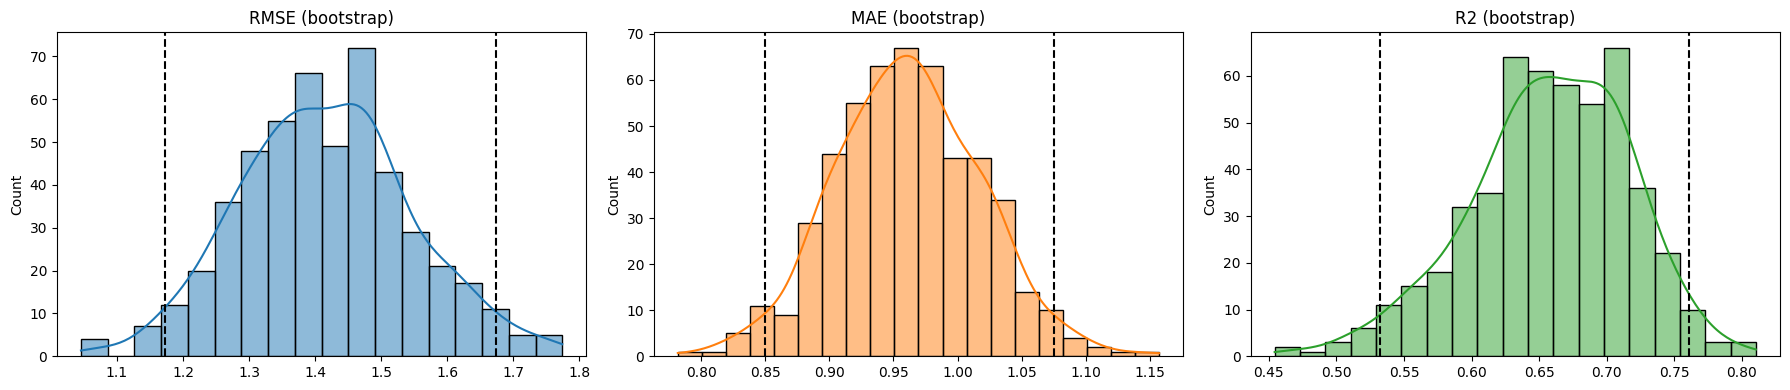

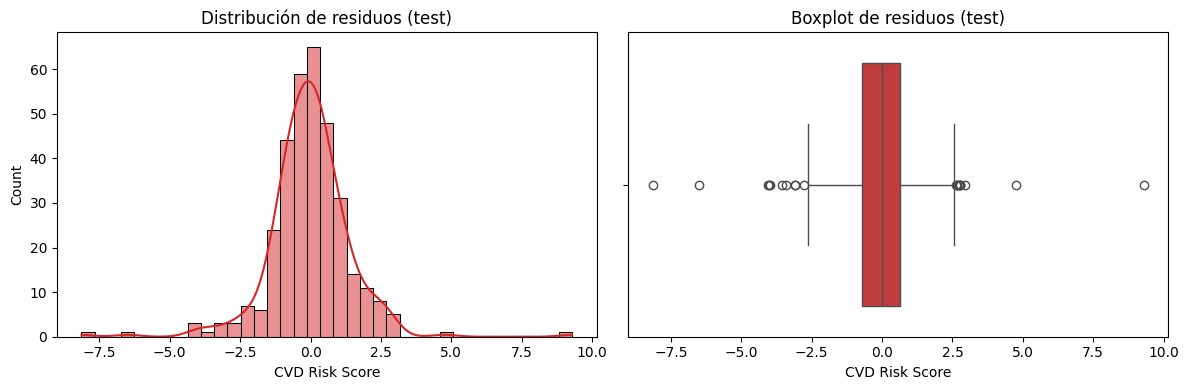

In [83]:
n_boot = 500
np.random.seed(42)

# --- Recuperar el estimador final con varias estrategias ---
model = None
# 1) si stability_info y best_row existen, usarlos
best_row_val = globals().get('best_row', None)
stability = globals().get('stability_info', None)
if stability is not None and best_row_val is not None:
    model_obj = stability.get(best_row_val, None)
    if model_obj is not None:
        model = getattr(model_obj, 'best_estimator_', model_obj)

# 2) si no, intentar deducir desde df_comparison (modelo con menor RMSE_test)
if model is None and 'df_comparison' in globals():
    try:
        dfc = globals()['df_comparison']
        if 'RMSE_test' in dfc.columns:
            idx = dfc['RMSE_test'].idxmin()
            # obtener etiqueta del modelo
            if 'Model' in dfc.columns:
                label = dfc.loc[idx, 'Model']
            else:
                label = dfc.index[idx]
            # intentar buscar en stability_info
            if stability is not None and label in stability:
                model_obj = stability[label]
                model = getattr(model_obj, 'best_estimator_', model_obj)
    except Exception:
        model = None

# 3) si aún no hay modelo, buscar variables candidatas en el kernel
if model is None:
    candidates = ['best_lasso_linear_model','best_lasso_poly_model','best_ridge','best_ridge_poly',
                  'pipeline_linear','pipeline_poly','mejor_modelo_poly','best_ridge']
    for name in candidates:
        if name in globals():
            cand = globals()[name]
            model = getattr(cand, 'best_estimator_', cand)
            break

# 4) último recurso: si existe 'best_params' y algún grid_*, intentar reconstruir (no implementado automáticamente)
if model is None:
    raise RuntimeError('No se encontró automáticamente el estimador final. Compruebe que `best_row`, `df_comparison` o alguno de los objetos candidatos exista en el kernel (p.ej. best_ridge, best_lasso_linear_model, pipeline_poly).')

# --- Ejecutar bootstrap ---
rmses = []
maes = []
r2s = []

n = len(X_test)
for i in range(n_boot):
    idx = np.random.choice(n, size=n, replace=True)
    Xb = X_test.iloc[idx]
    yb = y_test.iloc[idx]
    y_pred = model.predict(Xb)
    rmses.append(np.sqrt(mean_squared_error(yb, y_pred)))
    maes.append(mean_absolute_error(yb, y_pred))
    r2s.append(r2_score(yb, y_pred))

rmses = np.array(rmses)
maes = np.array(maes)
r2s = np.array(r2s)

summary = pd.DataFrame({
    'metric': ['RMSE','MAE','R2'],
    'mean': [rmses.mean(), maes.mean(), r2s.mean()],
    'std': [rmses.std(ddof=1), maes.std(ddof=1), r2s.std(ddof=1)],
    'ci_lower': [np.percentile(rmses, 2.5), np.percentile(maes, 2.5), np.percentile(r2s, 2.5)],
    'ci_upper': [np.percentile(rmses, 97.5), np.percentile(maes, 97.5), np.percentile(r2s, 97.5)]
})

print('Bootstrap (n={}) — resumen de métricas sobre test'.format(n_boot))
print(summary)

# Gráficas
fig, axes = plt.subplots(1,3, figsize=(18,4))
sns.histplot(rmses, kde=True, ax=axes[0], color='C0')
axes[0].axvline(summary.loc[0,'ci_lower'], color='k', linestyle='--')
axes[0].axvline(summary.loc[0,'ci_upper'], color='k', linestyle='--')
axes[0].set_title('RMSE (bootstrap)')

sns.histplot(maes, kde=True, ax=axes[1], color='C1')
axes[1].axvline(summary.loc[1,'ci_lower'], color='k', linestyle='--')
axes[1].axvline(summary.loc[1,'ci_upper'], color='k', linestyle='--')
axes[1].set_title('MAE (bootstrap)')

sns.histplot(r2s, kde=True, ax=axes[2], color='C2')
axes[2].axvline(summary.loc[2,'ci_lower'], color='k', linestyle='--')
axes[2].axvline(summary.loc[2,'ci_upper'], color='k', linestyle='--')
axes[2].set_title('R2 (bootstrap)')

plt.tight_layout()
plt.show()

# Residuos en test original
y_test_pred = model.predict(X_test)
resid = y_test - y_test_pred

fig, ax = plt.subplots(1,2,figsize=(12,4))
sns.histplot(resid, kde=True, ax=ax[0], color='C3')
ax[0].set_title('Distribución de residuos (test)')

sns.boxplot(x=resid, ax=ax[1], color='C3')
ax[1].set_title('Boxplot de residuos (test)')
plt.tight_layout()
plt.show()

bootstrap_results = {
    'rmses': rmses,
    'maes': maes,
    'r2s': r2s,
    'summary': summary
}

## 12. Análisis de resultados

### 12.1 Análisis cuantitativo

- ¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?

El modelo con el mejor desempeño fue la polinomial Lasso. Esta obtuvo las siguientes métricas sobre el conjunto test:

RMSE: 1.387,
MAE: 0.789 y
R^2: 0.674

- ¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no coincide, ¿cuál puede ser la explicación?

En nuestro caso sí: el modelo que obtuvo el menor RMSE promedio en la validación
cruzada (el polinomial Lasso) fue el que obtuvo el mejor desempeño de todos los modelos.

Si estos no coincidieran, podría ser explicado por fenómenos como fuga de información. Esto podría inflar artificialmente el rendimiento en validación cruzada y no replicarse en test.

- ¿El modelo con mejor métrica promedio es necesariamente el más adecuado? Justifica considerando también la desviación estándar del desempeño.

No necesariamente. El modelo con la mejor métrica promedio puede que no sea siempre el más adecuado ya que por más bajo que sea su error, puede que tenga una desviación mucho mayor. Esto indicaría que su rendimiento no es estable. Un modelo con métricas un poco peores pero desviación mucho menor puede ser más adecuado ya que se vuelve más consistente. 

- Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?

A medida que se aumentacomplejidad, el error disminuye de manera considerableentrenamiento, mientras que en validación este aumenta pero más moderadamente. Hay evidencia de sobreajuste en el punto en el que la curva de validación aumenta mucho más (entre grados 2 y 3).

- ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?

El término de lnalización de la regularizacón limita la magnitud de los coeficientes. Esto hace que las estimaciones sean más robustas a perturbaciones pequeñas. Por esta razón, los coeficientes son mucho más estables y así los modelos tienden a una desviación menor.  

- ¿Los intervalos de confianza obtenidos mediante bootstrapping sugieren estabilidad o alta variabilidad en el desempeño? ¿Qué implicaciones tiene esto?

Para el RMSE, hay una variabilidad alta. Las otras métricas tienen una estabilidad moderada. Esto implica que puede que le rendimiento sea un poco incierto. Esto no es bueno si se busca toamr decisiones médicas basado en esto, ya que se busca el mayor de consistencia posible.

### 12.2 Análisis cualitativo

- ¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?

num__BMI                                                                      2.238265
num__Estimated LDL (mg/dL)                                                    1.885622
num__Diabetes Status                                                          1.857691
num__Systolic BP 

Las variables seleccionadas como más relevantes por el modelo Lasso fueron: BMI ("BMI"), LDL estimado ("Estimated LDL (mg/dL)"), estatus diabético ("Diabetes Status") y Presión arterial sistólica ("Systolic BP").

- ¿Qué interpretación práctica tienen los coeficientes del modelo final en el contexto del riesgo cardiovascular?

Estos coeficientes son extremadamente relevantes para saber qué factores son los que más aumentan el riesgo de enfermedades cardiovasculares. Esto le ayuda a AlpesHearth a tener conocimiento más preciso sobre qué hábitos y aspectos se pueden mejorar de la vida de na persona para reducir estos riesgos.

- ¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?

Principalmente, el modelo más preciso usa relaciones no lineales. Esto hace que tenga una capacidad predictiva superior as que usan relaciones lineales. Sin embargo, los modelos lineales son mucho más fáciles de interpretar, pues se puede ver directamente cuanto impacto tiene cada factor sobre el riesgo de enfermedades cardiovasculares.

- ¿Qué decisiones estratégicas podría tomar AlpesHearth a partir de los resultados obtenidos?

A partir de los resultados obtenidos, AlpesHearth puede tomar decisiones sobre el enfoque que se le puede dar a las campañas preventivvas. Con un modelo más robusto, pueden dar un enfoque que ayude aún más a las personas a evitar riesgo cardiovascular a edades más avanzadas. Conociendo qué factores son los de mayor impacto, se puede evitar dar información que puede que no sea tan relevante o que no ayude tanto a prevenir riesgos. 

- ¿Mayor precisión implica necesariamente mayor valor para la organización?

Es preferible tener un modelo con precisión mayor a un modelo con precisión baja. Sin embargo, esto no siempre significa que tiene un mayor valor para la organización. Si un modelo tiene una precisión un poco menor, pero es mucho más consistente, o es de menor costo, puede que este le traiga más valor a la compañía. 

- ¿Un modelo más complejo necesariamente genera mayor valor empresarial? Discute considerando interpretabilidad, estabilidad y costo de implementación.

La estabilidad del modelo es importante, pues es mejor que el modelo sea consistente. Además, debe ser relativamente fácil de interpretar, especialmente en el entorno clínico o de negocio ya que se debe poder comunicar de manera clara. Adicionalmente, el costo es un factor muy importante ya que puede que no valga la pena invertir demasiado dinero por un modelo marginalmente más complejo. Por esto, una mayor complejidad no necesariamente significa un mayor valor empresarial.

### 12.3 Reflexión conceptual

- ¿Qué relación observas entre complejidad del modelo, capacidad de generalización y estabilidad del desempeño?

A medida que se aumenta la complejidad del modelo al introducir más terminos, puede que la capacidad de generalización aumente pero, al introducir más grados de libertad, la estabilidad del modelo disminuye. Esto se disminuye bastante con la regularización pero en general, el modelo se vuelve considerablemente más inestable a medida que se aumenta su complejidad. 

- ¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?

En los datos:

Puede que los datos no sean representativos de la población general. Los datos son tan solo 1600 sin tomar en cuenta los que se eliminaron como parte del proceso de limpieza. Por lo tanto, las conclusiones que se apliquen sobre este conjunto de datos puede que no apliquen a la población general. 

Puede que también existan errores en la manera en que se midieron los datos o inconsistencias clínicas. 

En el proceso de modelado:

Puede que los métodos de imputación hayan introducido patrones artificiales que luego son tomados en cuenta por el modelo, así en realidad no existan.

Puede que al eliminar un número de datos, patrones existentes se hayan disipado y no puedan ser identificados con la nueva cantidad de datos que sí fueron tomados en cuenta. 

- Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad de los modelos? Explique.

Si el tamaño de la muestra aumenta, se espera que haya una mayor estabilidad en los modelos. Esto es porque un mayor número de datos permite seleccionar características de manera más consistente. Se esperara que la desviación estándar de las métricas disminuya a medida que se introducen más datos. Además, al conocer más casos, el modelo puede predecir de mejor manera los comportamiento de la población en general. 

# 13. Uso IAG

### 13.1 Declaración de uso

La IA se usó para explicar conceptos y, en algunos casos, generar o depurar fragmentos de código en el notebook. Principalmente, se usó ChatGPT pero para las partes donde se buscaba generar código directamente en el notebook se usó copilot. El uso principal fue de redacción académica y apoyo conceptual, aunque también se consultó para estructura de código y arreglar errores que ocurrían al escribir código. También, con la IA se generó un esqueleto básico de la estructura del laboratorio para que este sea más organizado.

### 13.2 Prompts utilizdos

Abajo se encuentra la estructura principal de los prompts utilizados. Existieron interacciones menores y contextos diferentes en los prompts para ayudar con partes diferentes del laboratorio.

- Genera un esqueleto básico de código para poder hacer bootstrapping con el modelo de regresión elegido. Observa el modelo seleccionado y el código del modelo para que entiendas mejor como hacer esto... *interacciones menores de construcción del bootstrapping*
- Leyendo el notebook, es el modelo polinomial Lasso el mejor? Ayúdame a generar código que compare las métricas de cadaa modelo y sus desviaciones estándar. 
- Dame una estructura básica del laboratorio considerando que el enunciado pide lo siguiente...
- Me sale el siguiente error: *mensaje de error* en este bloque de código. De donde sale el problema y como lo puedo arreglar?
- Qué tipos de sesgo se pueden llegar a encontrar en los datos y que sesgo podría ser generado en el proceso de modelado?

### 13.3 Análisis crítico de resultado

¿Qué errores, imprecisiones o limitaciones se identificaron? 

Para algunas partes del código generado, la IA a veces usaba información de manera érronea. Por ejemplo, para la comparación de los modelos, asumía que también existiía un modelo lineal simple, pero usaba el modelo lineal regularizado. Esto era incorrecto, pues la misma información aparecía dos veces a pesar de ser clasificada como modelos diferentes. Este tipo de errores sucedían, en donde la ía asumía que algo era diferente a lo que realmente era y lo usaba de maneras incorrectas. Era necesario tener cuidado con estos errores al momento de implementar código. 

¿Qué conceptos del curso permitieron evaluar o mejorar la respuesta generada?

Para la construcción de los modelos con ayuda de la IA, fue importante entender el concepto de regularización y en general como funcionan los modelos polinomiales. Esto permitía verificar que en efecto el código que era generado por la IA era correcto. Además, las justificaciones de la IA al ayudar a decidir cual modelo era el mejor fueron soportadas por el conocimiento de por qué los modelos regulares tienden a ser más estables. 

### 13.4 Aportes propios del estudiante

Aunque la IA ayudó a entender por qué unos modelos eran mejores que otros, la decisión final del modelo elegido fue hecha por el estudiante, teniendo en cuenta conceptos del curso, además del contexto sobre la problemática de AlpesHearth proporcionado tanto en el primer laboratorio como en este. 

Se corrigieron fragmentos de código generados por la IA. Algunos fragmentos contenían errores de lógica o simplemente no hacían lo que se buscaba. En estos casos, era necesario que el estudiante revisara manualmente dichos fragmentos y cambiara las cosas que estuvieran incorrectas. 

En el proceso se aprendió la importancia de validar lo que hace la IA. En muchos casos se equivoca o toma decisiones que pueden no tener sentido. Además, es necesario pensar de la IA no como un programador que conoce todo el proyecto, sino como uno que no conoce nada. De esta manera, nosotros le damos las instrucciones a la IA y entre mejor entendamos qué es lo que se busca lograr, mejor va a ser el código generado. 